ustar   = 0.3703 m/s
fw      = 0.0686
Aorb    = 3.1831 m
delta_w = 0.2947 m


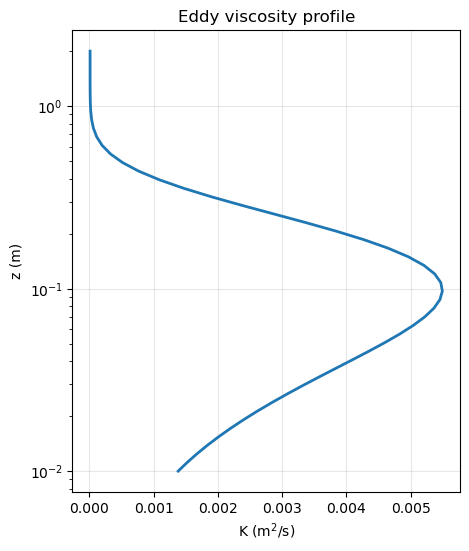

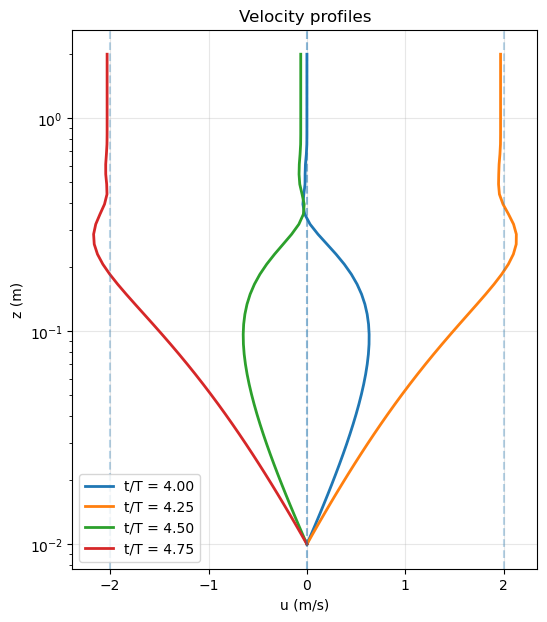

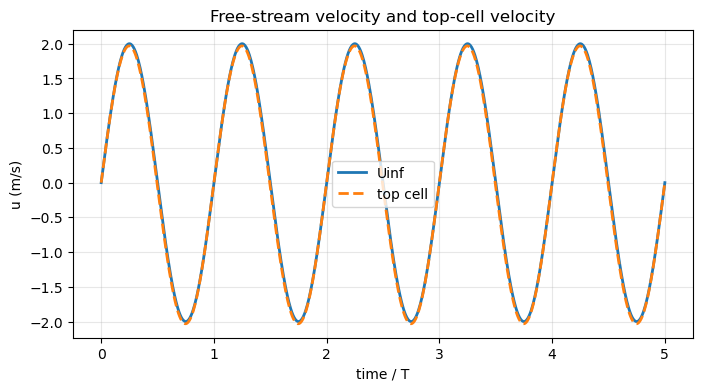

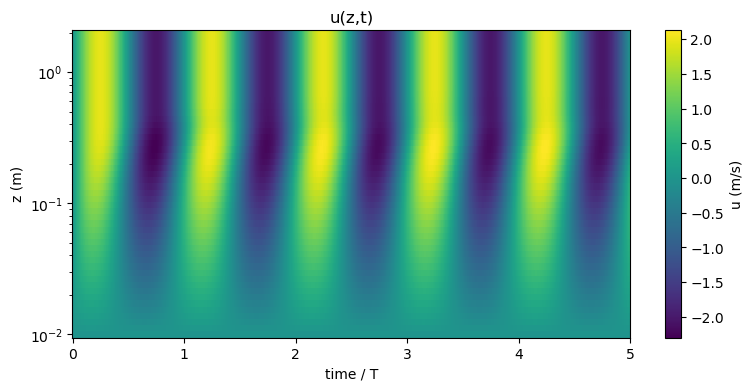

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# This code was generated by ChatGPT

# ============================================================
# Utility functions
# ============================================================

def make_log_grid(z0=0.01, zmax=2.0, nz=50):
    """
    Logarithmically spaced vertical grid from z0 to zmax.
    """
    return np.geomspace(z0, zmax, nz)


def estimate_ustar_wave(Ub, T, ks):
    """
    Estimate wave friction velocity from free-stream orbital velocity amplitude.

    Parameters
    ----------
    Ub : float
        Free-stream orbital velocity amplitude (m/s)
    T : float
        Wave period (s)
    ks : float
        Nikuradse roughness height (m)

    Returns
    -------
    ustar : float
        Wave friction velocity (m/s)
    fw : float
        Wave friction factor (-)
    Aorb : float
        Orbital semi-excursion amplitude (m)
    """
    omega = 2 * np.pi / T
    Aorb = Ub / omega

    ratio = Aorb / ks
    fw = np.exp(5.213 * ratio**(-0.194) - 5.977)

    ustar = Ub * np.sqrt(0.5 * fw)
    return ustar, fw, Aorb


def eddy_viscosity(z, ustar, T, kappa=0.41, Kbg=1e-5):
    """
    Eddy viscosity profile:
        K = Kbg + kappa * ustar * z * exp(-3*z/delta_w)

    where
        delta_w = ustar / (2*omega)

    Parameters
    ----------
    z : ndarray
        Height above bed (m)
    ustar : float
        Shear velocity (m/s)
    T : float
        Wave period (s)
    kappa : float
        von Karman constant
    Kbg : float
        Background viscosity (m^2/s)

    Returns
    -------
    K : ndarray
        Eddy viscosity profile (m^2/s)
    delta_w : float
        Wave boundary layer thickness scale (m)
    """
    omega = 2 * np.pi / T
    delta_w = ustar / (2 * omega)

    Kturb = kappa * ustar * z * np.exp(-3.0 * z / delta_w)
    K = Kbg + Kturb

    return K, delta_w


# ============================================================
# Linear system builder
# ============================================================

def build_matrix(z, K, dt):
    """
    Build matrix for implicit Euler time stepping of

        du/dt = d/dz ( K du/dz ) + forcing(t)

    Boundary conditions:
        bottom: u = 0
        top   : du/dz = 0

    Uses central differencing / flux form on a nonuniform grid.
    """
    n = len(z)
    A = np.zeros((n, n))

    # bottom boundary: Dirichlet, u = 0
    A[0, :] = 0.0
    A[0, 0] = 1.0

    # interior nodes
    for i in range(1, n - 1):
        dzm = z[i]   - z[i - 1]
        dzp = z[i+1] - z[i]
        dzc = 0.5 * (dzm + dzp)

        Km = 0.5 * (K[i] + K[i - 1])   # K at i-1/2
        Kp = 0.5 * (K[i] + K[i + 1])   # K at i+1/2

        am = dt * Km / (dzm * dzc)
        ap = dt * Kp / (dzp * dzc)

        A[i, i - 1] = -am
        A[i, i    ] = 1.0 + am + ap
        A[i, i + 1] = -ap

    # top boundary: Neumann, du/dz = 0  ->  u_N - u_{N-1} = 0
    A[-1, :] = 0.0
    A[-1, -2] = -1.0
    A[-1, -1] =  1.0

    return A


# ============================================================
# Main solver
# ============================================================

def solve_wave_boundary_layer(
    T=10.0,
    Ub=2.0,
    z0=0.01,
    zmax=2.0,
    nz=50,
    nperiods=4,
    nt_per_period=200,
    ks=None,
    kappa=0.41,
    Kbg=1e-5,
):
    """
    Solve a 1D vertical wave boundary layer model:

        du/dt = d/dz ( K du/dz ) + dUinf/dt

    with
        Uinf(t) = Ub * sin(omega t)

    so that
        dUinf/dt = Ub * omega * cos(omega t)

    Boundary conditions:
        u(z0,t)   = 0
        du/dz(top)= 0

    Parameters
    ----------
    T : float
        Wave period (s)
    Ub : float
        Free-stream orbital velocity amplitude (m/s)
    z0 : float
        Bottom roughness/reference height (m)
    zmax : float
        Top of domain (m)
    nz : int
        Number of vertical levels
    nperiods : int
        Number of periods to simulate
    nt_per_period : int
        Time steps per period
    ks : float or None
        Nikuradse roughness height (m). If None, use ks = 30*z0
    kappa : float
        von Karman constant
    Kbg : float
        Background viscosity (m^2/s)

    Returns
    -------
    out : dict
        Dictionary of model fields and parameters
    """
    if ks is None:
        ks = 30.0 * z0

    omega = 2.0 * np.pi / T
    dt = T / nt_per_period
    t = np.arange(0.0, nperiods * T + dt, dt)

    # free-stream velocity and acceleration
    Uinf = Ub * np.sin(omega * t)
    dUinf_dt = Ub * omega * np.cos(omega * t)

    # vertical grid
    z = make_log_grid(z0=z0, zmax=zmax, nz=nz)

    # estimate ustar and eddy viscosity
    ustar, fw, Aorb = estimate_ustar_wave(Ub=Ub, T=T, ks=ks)
    K, delta_w = eddy_viscosity(z=z, ustar=ustar, T=T, kappa=kappa, Kbg=Kbg)

    # system matrix
    M = build_matrix(z=z, K=K, dt=dt)

    # solution array
    u = np.zeros((len(t), nz))

    # initial condition consistent with sine forcing:
    # Uinf(0) = 0, so zero everywhere is acceptable
    u[0, :] = 0.0
    u[0, 0] = 0.0

    # time stepping
    for n in range(len(t) - 1):
        rhs = u[n, :].copy()

        # apply body force over interior nodes
        rhs[1:-1] += dt * dUinf_dt[n + 1]

        # bottom BC: u = 0
        rhs[0] = 0.0

        # top BC: du/dz = 0
        rhs[-1] = 0.0

        u[n + 1, :] = np.linalg.solve(M, rhs)

    return {
        "t": t,
        "z": z,
        "u": u,
        "Uinf": Uinf,
        "dUinf_dt": dUinf_dt,
        "K": K,
        "ustar": ustar,
        "fw": fw,
        "Aorb": Aorb,
        "delta_w": delta_w,
        "omega": omega,
        "dt": dt,
        "T": T,
        "Ub": Ub,
        "z0": z0,
        "zmax": zmax,
        "nz": nz,
        "ks": ks,
        "Kbg": Kbg,
    }


# ============================================================
# Example run
# ============================================================

out = solve_wave_boundary_layer(
    T=10.0,
    Ub=2.0,
    z0=0.01,
    zmax=2.0,
    nz=50,
    nperiods=5,
    nt_per_period=200,
    Kbg=1e-5,
)

print(f"ustar   = {out['ustar']:.4f} m/s")
print(f"fw      = {out['fw']:.4f}")
print(f"Aorb    = {out['Aorb']:.4f} m")
print(f"delta_w = {out['delta_w']:.4f} m")


# ============================================================
# Plot: eddy viscosity profile
# ============================================================

fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(out["K"], out["z"], linewidth=2)
ax.set_yscale("log")
ax.set_xlabel("K (m$^2$/s)")
ax.set_ylabel("z (m)")
ax.set_title("Eddy viscosity profile")
ax.grid(True, alpha=0.3)
plt.show()


# ============================================================
# Plot: selected velocity profiles during final period
# ============================================================

t = out["t"]
z = out["z"]
u = out["u"]
T = out["T"]

fig, ax = plt.subplots(figsize=(6, 7))

for frac in [0.00, 0.25, 0.50, 0.75]:
    tt = 4 * T + frac * T
    it = np.argmin(np.abs(t - tt))
    ax.plot(u[it, :], z, linewidth=2, label=f"t/T = {t[it]/T:.2f}")

# also plot free-stream value as vertical dashed lines
for frac in [0.00, 0.25, 0.50, 0.75]:
    tt = 4 * T + frac * T
    Uinf_tt = out["Ub"] * np.sin(out["omega"] * tt)
    ax.axvline(Uinf_tt, linestyle="--", alpha=0.3)

ax.set_xlabel("u (m/s)")
ax.set_ylabel("z (m)")
ax.set_yscale("log")
ax.set_title("Velocity profiles")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


# ============================================================
# Plot: top-cell velocity versus free-stream velocity
# ============================================================

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t / T, out["Uinf"], label="Uinf", linewidth=2)
ax.plot(t / T, u[:, -1], "--", label="top cell", linewidth=2)
ax.set_xlabel("time / T")
ax.set_ylabel("u (m/s)")
ax.set_title("Free-stream velocity and top-cell velocity")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


# ============================================================
# Plot: Hovmoller diagram
# ============================================================

fig, ax = plt.subplots(figsize=(9, 4))
pcm = ax.pcolormesh(t / T, z, u.T, shading="auto")
ax.set_yscale("log")
ax.set_xlabel("time / T")
ax.set_ylabel("z (m)")
ax.set_title("u(z,t)")
cb = plt.colorbar(pcm, ax=ax)
cb.set_label("u (m/s)")
plt.show()